In [1]:
import os
import sys
src_dir = "../../src"
if src_dir not in sys.path:
    sys.path.append(src_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import axes3d
from datetime import datetime
import seaborn as sns
import random
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
from filterpy.monte_carlo import (
    multinomial_resample, residual_resample, systematic_resample, stratified_resample
)
from utils.error_report import get_error_from_list, get_error_report
from utils import normalize_angles, lla_to_enu

from data_loader import DataLoader
from configs.configs import MeasurementDataEnum, SetupEnum, SamplingEnum, ErrorEnum
import scipy.stats as stats
from scipy.stats import multivariate_normal
from kalman_filters.extended_kalman_filter import ExtendedKalmanFilter
from kalman_filters.unscented_kalman_filter import UnscentedKalmanFilter
from kalman_filters.ensemble_kalman_filter import EnsembleKalmanFilter
from kalman_filters.particle_filter import ParticleFilter, ResamplingAlgorithms
from kalman_filters.cubature_kalman_filter import CubatureKalmanFilter
from numpy.linalg import norm

from ahrs.filters import Madgwick

%matplotlib inline
np.random.seed(777)

In [2]:
root_path = "../../"

file_export_path = os.path.join(root_path, "exports/UAV")

uav_root_path = os.path.join(root_path, "data/UAV/log0005")
uav_reference_path = os.path.join(uav_root_path, "combined_reference.csv")

px4_root_path = os.path.join(uav_root_path, "px4")
px4_imu0_acc_path = os.path.join(px4_root_path, "log_91_2024-5-29-15-52-22_sensor_accel_0.csv")
px4_imu1_acc_path = os.path.join(px4_root_path, "log_91_2024-5-29-15-52-22_sensor_accel_1.csv")
px4_imu0_gyr_path = os.path.join(px4_root_path, "log_91_2024-5-29-15-52-22_sensor_gyro_0.csv")
px4_imu1_gyr_path = os.path.join(px4_root_path, "log_91_2024-5-29-15-52-22_sensor_gyro_1.csv")
px4_gps_path = os.path.join(px4_root_path, "log_91_2024-5-29-15-52-22_sensor_gps_0.csv")

voxl_root_path = os.path.join(uav_root_path, "voxl")
voxl_imu0_path = os.path.join(voxl_root_path, "imu0/data.csv")
voxl_imu1_path = os.path.join(voxl_root_path, "imu1/data.csv")
voxl_qvio_path = os.path.join(voxl_root_path, "qvio/data.csv")

ref_df = pd.read_csv(uav_reference_path)
px4_imu0_acc_df = pd.read_csv(px4_imu0_acc_path)
px4_imu1_acc_df = pd.read_csv(px4_imu1_acc_path)
px4_imu0_gyr_df = pd.read_csv(px4_imu0_gyr_path)
px4_imu1_gyr_df = pd.read_csv(px4_imu1_gyr_path)
px4_gps_df = pd.read_csv(px4_gps_path)
voxl_imu0_df = pd.read_csv(voxl_imu0_path)
voxl_imu1_df = pd.read_csv(voxl_imu1_path)
voxl_qvio_df = pd.read_csv(voxl_qvio_path)

FileNotFoundError: [Errno 2] No such file or directory: '../../data/UAV/log0005/combined_reference.csv'

In [3]:
from decimal import Decimal, getcontext
getcontext().prec = 10
def int2float_lla(x):
    return float(Decimal(x / Decimal(10**(len(str(x)) - 2))))
    
px4_gps_df['lat'] = px4_gps_df['lat'].apply(lambda x: int2float_lla(x))
px4_gps_df['lon'] = px4_gps_df['lon'].apply(lambda x: int2float_lla(x))
px4_gps_df['alt'] = px4_gps_df['alt'].apply(lambda x: int2float_lla(x))

In [4]:
origin = px4_gps_df[['lon', 'lat', 'alt']].iloc[0].values
enu_pose = lla_to_enu(px4_gps_df[['lon', 'lat', 'alt']].values.T, origin).T

px4_gps_df = pd.concat([
    px4_gps_df,
    pd.DataFrame(enu_pose, columns=['east', 'north', 'up'])
], axis=1)

In [5]:
ref_df['device'].value_counts()

device
voxl_imu_1    279156
voxl_imu_0    248854
voxl_vo         3687
px4_imu_1        200
px4_imu_0        200
px4_gps          100
Name: count, dtype: int64

In [6]:
ref_df['type'].value_counts()

type
acc     264205
gyr     264005
vo        3687
gyro       200
gps        100
Name: count, dtype: int64

In [7]:
time_update = ['voxl_imu_0', 'voxl_imu_1', 'px4_imu_0', 'px4_imu_1']
measurement_update = ['voxl_vo', 'px4_gps']

SENSOR_SLIP_THRESHOLD = 2 # 2 seconds

def get_config(timestamp):

    return {
        'acc': {
            'voxl_imu_0': {
                'index': 0,
                'last_timestamp': timestamp,
                'columns': ['AX(m/s2)', 'AY(m/s2)', 'AZ(m/s2)'],
                'df': voxl_imu0_df,
            },
            'voxl_imu_1': {
                'index': 0,
                'last_timestamp': timestamp,
                'columns': ['AX(m/s2)', 'AY(m/s2)', 'AZ(m/s2)'],
                'df': voxl_imu1_df,
            },
            'px4_imu_0': {
                'index': 0,
                'last_timestamp': timestamp,
                'columns': ['x', 'y', 'z'],
                'df': px4_imu0_acc_df,
            },
            'px4_imu_1': {
                'index': 0,
                'last_timestamp': timestamp,
                'columns': ['x', 'y', 'z'],
                'df': px4_imu1_acc_df,
            }
        },
        'gyr': {
            'voxl_imu_0': {
                'index': 0,
                'last_timestamp': timestamp,
                'columns': ['GX(rad/s)', 'GY(rad/s)', 'GZ(rad/s)'],
                'df': voxl_imu0_df,
            },
            'voxl_imu_1': {
                'index': 0,
                'last_timestamp': timestamp,
                'columns': ['GX(rad/s)', 'GY(rad/s)', 'GZ(rad/s)'],
                'df': voxl_imu1_df,
            },
            'px4_imu_0': {
                'index': 0,
                'last_timestamp': timestamp,
                'columns': ['x', 'y', 'z'],
                'df': px4_imu0_gyr_df,
            },
            'px4_imu_1': {
                'index': 0,
                'last_timestamp': timestamp,
                'columns': ['x', 'y', 'z'],
                'df': px4_imu1_gyr_df,
            }
        },
        'gps': {
            'px4_gps': {
                'index': 0,
                'last_timestamp': timestamp,
                'columns': ['lat', 'lon', 'alt', 'east', 'north', 'up', 'vel_m_s', 'vel_n_m_s', 'vel_e_m_s', 'vel_d_m_s'],
                'df': px4_gps_df,
            },
        },
        'vo': {
            'voxl_vo': {
                'index': 0,
                'last_timestamp': timestamp,
                'columns': voxl_qvio_df.columns.tolist(),
                'df': voxl_qvio_df,
            },
        },
    }

#### Visualize UAV trajectory

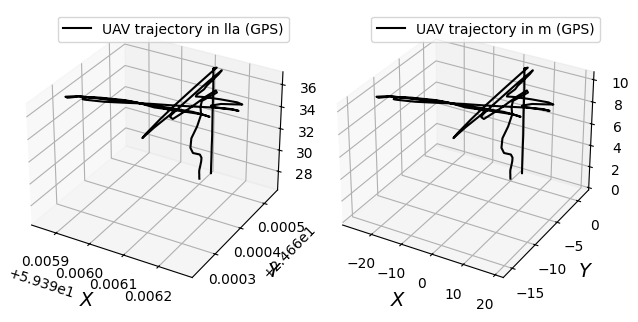

In [8]:

fig = plt.figure()

ax1 = fig.add_subplot(121, projection='3d')
x = px4_gps_df['lat'].values
y = px4_gps_df['lon'].values
z = px4_gps_df['alt'].values
ax1.plot(x, y, z, label='UAV trajectory in lla (GPS)', color='black')
ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)


ax2 = fig.add_subplot(122, projection='3d')
x = px4_gps_df['north'].values
y = px4_gps_df['east'].values
z = px4_gps_df['up'].values
ax2.plot(x, y, z, label='UAV trajectory in m (GPS)', color='black')
ax2.legend()

ax2.set_xlabel('$X$', fontsize=14)
ax2.set_ylabel('$Y$', fontsize=14)
ax2.set_zlabel('$Z$', fontsize=14)

fig.tight_layout()
plt.show()

## Single IMU (IMU0 from voxl side)

Accoding to the Modal AI documentation, IMU0 on the voxl side is preferentially used since it is newer and better performance.
https://docs.modalai.com/voxl-flight-datasheet-imus/

In [12]:
single_df = ref_df.loc[((ref_df["device"] == "voxl_imu_0") & (ref_df["type"] == "acc")) | (ref_df["device"] == "px4_gps")]

### EKF

In [27]:
x = np.array([
    [px4_gps_df.iloc[0]['east']],
    [px4_gps_df.iloc[0]['north']],
    [px4_gps_df.iloc[0]['up']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.01, 0.01, 0.01, 0.0035, 0.0035, 0.0035])
r = np.array([0.1, 0.1, 0.1])

In [28]:
ekf = ExtendedKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=np.array([]),
    r_gps=r,
    setup=SetupEnum.SETUP_1
)

In [29]:
timestamp = single_df.iloc[0]['timestamp']
df_reference = get_config(timestamp=timestamp)
original_position = px4_gps_df[['lon', 'lat', 'alt']].iloc[0].values

mu_x = [x[0][0]]
mu_y = [x[0][0]]
mu_z = [x[0][0]]

N = len(single_df.loc[single_df["type"] == "gps"].values)
for idx in tqdm(range(0, N)):
    data_ref = single_df.loc[single_df["type"] == "gps"].iloc[idx]
    sensor = df_reference[data_ref['type']][data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000

    if dt < SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in time_update:
            # Call Time update step
            gyro_sensor = df_reference['gyr'][data_ref['device']]
            w_data = sensor['df'].iloc[gyro_sensor['index']][gyro_sensor['columns']]
            a = data.values
            w = w_data.values
            u = np.array([
                a,
                w
            ]).flatten()
            ekf.predict_setup1_2(u, dt, ekf.Q)
        elif data_ref['device'] in measurement_update:
            # Call Measurement update step
            gps_enu = lla_to_enu(
                px4_gps_df[['lon', 'lat', 'alt']].iloc[sensor['index']:sensor['index'] + 1].values.T, 
                original_position
            ).T[0]
            z = np.array([
                gps_enu[0],
                gps_enu[1],
                gps_enu[2],
            ])
            ekf.update(z, R=ekf.R_gps)
            
            x_hat = ekf.x.copy()
            mu_x.append(x_hat[0, 0])
            mu_y.append(x_hat[1, 0])
            mu_z.append(x_hat[2, 0])
     
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1

100%|████████████████████████████████████████| 100/100 [00:00<00:00, 197.16it/s]


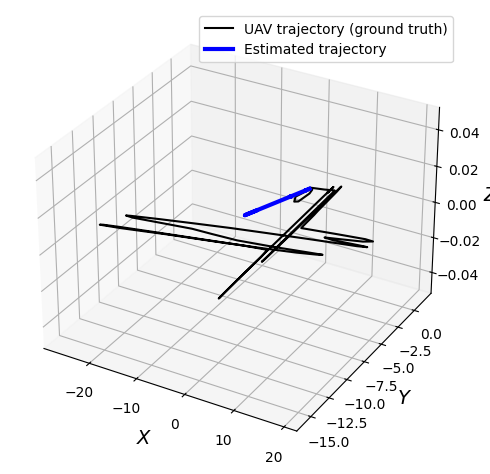

In [30]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')

ax1.plot(px4_gps_df['north'].values, 
         px4_gps_df['east'].values, 
         px4_gps_df['up'].values, 
         label='UAV trajectory (ground truth)', 
         color='black')
ax1.plot(mu_x, mu_y, mu_z, label='Estimated trajectory', color='blue', lw=3)

ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)
fig.tight_layout()

### UKF

In [385]:
x = np.array([
    [px4_gps_df.iloc[0]['east']],
    [px4_gps_df.iloc[0]['north']],
    [px4_gps_df.iloc[0]['up']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r = np.array([0.1, 0.1, 0.1])

alpha_setup = 0.0001
beta_setup = 2.
kappa_setup = 0.

ukf = UnscentedKalmanFilter(
    x=x.copy(), 
    P=P.copy(),
    H=H.copy(), 
    q=q,
    r_vo=np.array([]),
    r_gps=r,
    alpha=alpha_setup, 
    beta=beta_setup, 
    kappa=kappa_setup,
    setup=SetupEnum.SETUP_1
)

In [386]:
timestamp = single_df.iloc[0]['timestamp']
df_reference = get_config(timestamp=timestamp)
original_position = px4_gps_df[['lon', 'lat', 'alt']].iloc[0].values

mu_x = [x[0][0]]
mu_y = [x[0][0]]
mu_z = [x[0][0]]

N = len(single_df.values)
for idx in tqdm(range(0, N)):
    data_ref = single_df.iloc[idx]
    sensor = df_reference[data_ref['type']][data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000

    if dt < SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in time_update:
            # Call Time update step
            gyro_sensor = df_reference['gyr'][data_ref['device']]
            w_data = sensor['df'].iloc[gyro_sensor['index']][gyro_sensor['columns']]
            a = data.values
            w = w_data.values
            u = np.array([
                a,
                w
            ]).flatten()
            ukf.predict_setup1_2(u, dt, ukf.Q)
        elif data_ref['device'] in measurement_update:
            # Call Measurement update step
            gps_enu = lla_to_enu(
                px4_gps_df[['lon', 'lat', 'alt']].iloc[sensor['index']:sensor['index'] + 1].values.T, 
                original_position
            ).T[0]
            z = np.array([
                gps_enu[0],
                gps_enu[1],
                gps_enu[2],
            ])
            ukf.update(z, R=ukf.R_gps)
            
            x_hat = ukf.x.copy()
            mu_x.append(x_hat[0, 0])
            mu_y.append(x_hat[1, 0])
            mu_z.append(x_hat[2, 0])
     
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1

100%|███████████████████████████████████████████████████████████████████████████████| 124527/124527 [01:12<00:00, 1721.97it/s]


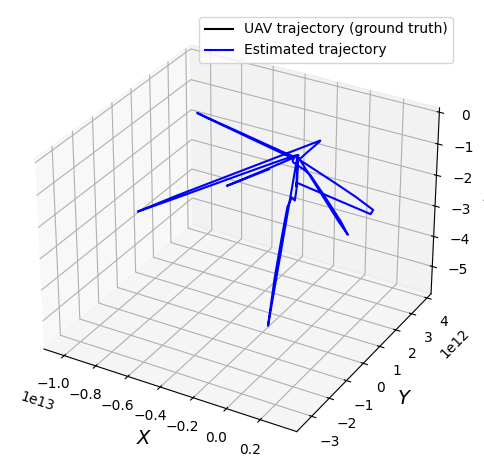

In [387]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')

ax1.plot(px4_gps_df['north'].values, 
         px4_gps_df['east'].values, 
         px4_gps_df['up'].values, 
         label='UAV trajectory (ground truth)', 
         color='black')
ax1.plot(mu_x, mu_y, mu_z, label='Estimated trajectory', color='blue')

ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)
fig.tight_layout()

### PF

In [370]:
x = np.array([
    [px4_gps_df.iloc[0]['east']],
    [px4_gps_df.iloc[0]['north']],
    [px4_gps_df.iloc[0]['up']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r = np.array([0.1, 0.1, 0.1])

In [371]:
pf = ParticleFilter(
    N=2048, 
    x_dim=x.shape[0], 
    H=H.copy(), 
    q=q,
    r_vo=np.array([]),
    r_gps=r,
    setup=SetupEnum.SETUP_1,
    resampling_algorithm=ResamplingAlgorithms.STRATIFIED)
pf.create_gaussian_particles(mean=x.copy(), var=P.copy())

In [372]:
timestamp = single_df.iloc[0]['timestamp']
df_reference = get_config(timestamp=timestamp)
original_position = px4_gps_df[['lon', 'lat', 'alt']].iloc[0].values

mu_x = [x[0][0]]
mu_y = [x[0][0]]
mu_z = [x[0][0]]

N = len(single_df.values)
for idx in tqdm(range(0, N)):
    data_ref = single_df.iloc[idx]
    sensor = df_reference[data_ref['type']][data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000

    if dt < SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in time_update:
            # Call Time update step
            gyro_sensor = df_reference['gyr'][data_ref['device']]
            w_data = sensor['df'].iloc[gyro_sensor['index']][gyro_sensor['columns']]
            a = data.values
            w = w_data.values
            u = np.array([
                a,
                w
            ]).flatten()
            pf.predict_setup1_2(u, dt, pf.Q)
        elif data_ref['device'] in measurement_update:
            # Call Measurement update step
            gps_enu = lla_to_enu(
                px4_gps_df[['lon', 'lat', 'alt']].iloc[sensor['index']:sensor['index'] + 1].values.T, 
                original_position
            ).T[0]
            z = np.array([
                gps_enu[0],
                gps_enu[1],
                gps_enu[2],
            ])
            pf.update(z, R=pf.R_gps)
            
            x_hat, _ = pf.estimate()
            mu_x.append(x_hat[0])
            mu_y.append(x_hat[1])
            mu_z.append(x_hat[2])
     
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1

100%|█████████████████████████████████████████████████████████████████████████████████| 124527/124527 [31:44<00:00, 65.40it/s]


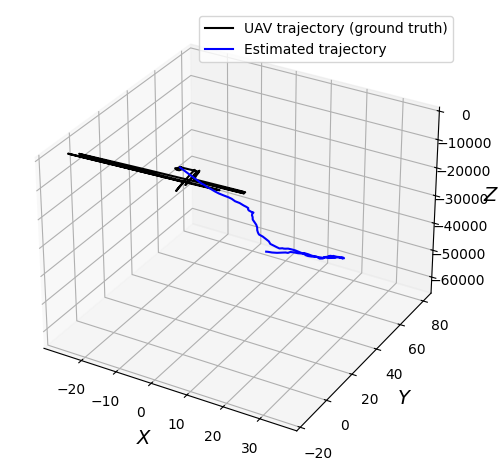

In [373]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')

ax1.plot(px4_gps_df['north'].values, 
         px4_gps_df['east'].values, 
         px4_gps_df['up'].values, 
         label='UAV trajectory (ground truth)', 
         color='black')
ax1.plot(mu_x, mu_y, mu_z, label='Estimated trajectory', color='blue')

ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)
fig.tight_layout()

### EnKF

In [374]:
x = np.array([
    [px4_gps_df.iloc[0]['east']],
    [px4_gps_df.iloc[0]['north']],
    [px4_gps_df.iloc[0]['up']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r = np.array([0.1, 0.1, 0.1])

n_ensemble = 64
enkf = EnsembleKalmanFilter(
    N=n_ensemble, 
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=np.array([]),
    r_gps=r,
    setup=SetupEnum.SETUP_1)
    

In [375]:
timestamp = single_df.iloc[0]['timestamp']
df_reference = get_config(timestamp=timestamp)
original_position = px4_gps_df[['lon', 'lat', 'alt']].iloc[0].values

mu_x = [x[0][0]]
mu_y = [x[0][0]]
mu_z = [x[0][0]]

N = len(single_df.values)
for idx in tqdm(range(0, N)):
    data_ref = single_df.iloc[idx]
    sensor = df_reference[data_ref['type']][data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000

    if dt < SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in time_update:
            # Call Time update step
            gyro_sensor = df_reference['gyr'][data_ref['device']]
            w_data = sensor['df'].iloc[gyro_sensor['index']][gyro_sensor['columns']]
            a = data.values
            w = w_data.values
            u = np.array([
                a,
                w
            ]).flatten()
            enkf.predict_setup1_2(u, dt, enkf.Q)
        elif data_ref['device'] in measurement_update:
            # Call Measurement update step
            gps_enu = lla_to_enu(
                px4_gps_df[['lon', 'lat', 'alt']].iloc[sensor['index']:sensor['index'] + 1].values.T, 
                original_position
            ).T[0]
            z = np.array([
                gps_enu[0],
                gps_enu[1],
                gps_enu[2],
            ])
            enkf.update(z, R=enkf.R_gps)
            
            x_hat = enkf.x.copy()
            mu_x.append(x_hat[0])
            mu_y.append(x_hat[1])
            mu_z.append(x_hat[2])
     
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1

100%|███████████████████████████████████████████████████████████████████████████████| 124527/124527 [01:42<00:00, 1213.16it/s]


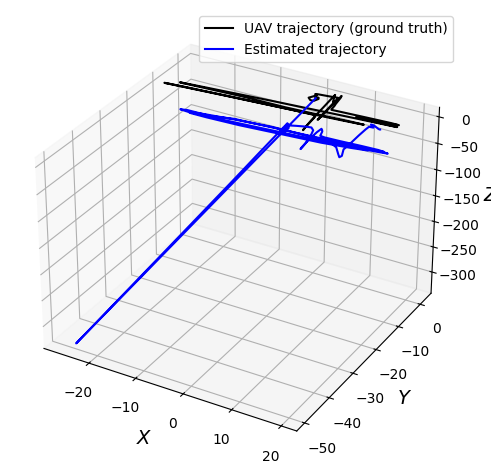

In [382]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')

ax1.plot(px4_gps_df['north'].values, 
         px4_gps_df['east'].values, 
         px4_gps_df['up'].values, 
         label='UAV trajectory (ground truth)', 
         color='black')
ax1.plot(mu_y, mu_x, mu_z, label='Estimated trajectory', color='blue')

ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)
fig.tight_layout()

### CKF

In [391]:
x = np.array([
    [px4_gps_df.iloc[0]['east']],
    [px4_gps_df.iloc[0]['north']],
    [px4_gps_df.iloc[0]['up']],
    [0.],
    [0.],
    [0.],
    [1.],
    [0.],
    [0.],
    [0.]
])
P = np.eye(x.shape[0]) * 0.1
H = np.array([
    [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]
])
q = np.array([0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.01, 0.01, 0.01, 0.01])
r = np.array([0.1, 0.1, 0.1])

ckf = CubatureKalmanFilter(
    x=x.copy(), 
    P=P.copy(), 
    H=H.copy(),
    q=q,
    r_vo=np.array([]),
    r_gps=r,
    setup=SetupEnum.SETUP_1,
)
    

In [392]:
timestamp = single_df.iloc[0]['timestamp']
df_reference = get_config(timestamp=timestamp)
original_position = px4_gps_df[['lon', 'lat', 'alt']].iloc[0].values

mu_x = [x[0][0]]
mu_y = [x[0][0]]
mu_z = [x[0][0]]

N = len(single_df.values)
for idx in tqdm(range(0, N)):
    data_ref = single_df.iloc[idx]
    sensor = df_reference[data_ref['type']][data_ref['device']]
    data = sensor['df'].iloc[sensor['index']][sensor['columns']]
    dt = (data_ref['timestamp'] - sensor['last_timestamp']) / 1_000_000

    if dt < SENSOR_SLIP_THRESHOLD:
        # Call Kalman Filter step
        if data_ref['device'] in time_update:
            # Call Time update step
            gyro_sensor = df_reference['gyr'][data_ref['device']]
            w_data = sensor['df'].iloc[gyro_sensor['index']][gyro_sensor['columns']]
            a = data.values
            w = w_data.values
            u = np.array([
                a,
                w
            ]).flatten()
            ckf.predict_setup1_2(u, dt, enkf.Q)
        elif data_ref['device'] in measurement_update:
            # Call Measurement update step
            gps_enu = lla_to_enu(
                px4_gps_df[['lon', 'lat', 'alt']].iloc[sensor['index']:sensor['index'] + 1].values.T, 
                original_position
            ).T[0]
            z = np.array([
                gps_enu[0],
                gps_enu[1],
                gps_enu[2],
            ])
            ckf.update(z, R=ckf.R_gps)
            
            x_hat = ckf.x.copy()
            mu_x.append(x_hat[0, 0])
            mu_y.append(x_hat[1, 0])
            mu_z.append(x_hat[2, 0])
     
    sensor['last_timestamp'] = data_ref['timestamp']
    sensor['index'] += 1

100%|███████████████████████████████████████████████████████████████████████████████| 124527/124527 [01:12<00:00, 1709.20it/s]


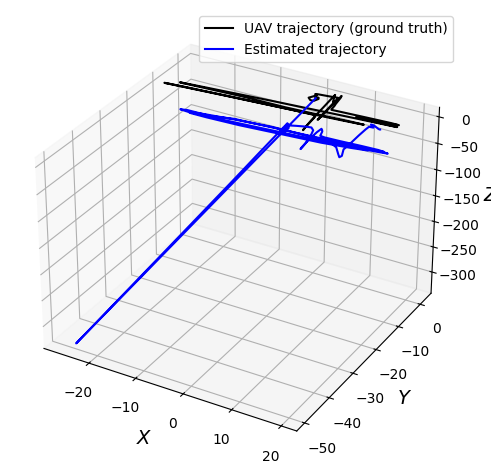

In [393]:
fig = plt.figure()

ax1 = fig.add_subplot(111, projection='3d')

ax1.plot(px4_gps_df['north'].values, 
         px4_gps_df['east'].values, 
         px4_gps_df['up'].values, 
         label='UAV trajectory (ground truth)', 
         color='black')
ax1.plot(mu_y, mu_x, mu_z, label='Estimated trajectory', color='blue')

ax1.legend()
ax1.set_xlabel('$X$', fontsize=14)
ax1.set_ylabel('$Y$', fontsize=14)
ax1.set_zlabel('$Z$', fontsize=14)
fig.tight_layout()